In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split


In [6]:
data=pd.read_csv("day.csv")
data.head()
#predecir demanda demanda de bicicletas Mediante Regresion Lineal
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


Columna	¿Por qué usar One-Hot?
season	Los números 1, 2, 3, 4 son etiquetas (Primavera, Verano...). Un modelo podría pensar erróneamente que el "4" es más importante o "mayor" que el "1", cuando solo son estaciones diferentes.
weathersit	Representa el clima (1: Despejado, 2: Niebla, 3: Lluvia). El One-Hot ayuda a separar el efecto de la lluvia del efecto de un día soleado.
weekday	Transforma el día de la semana (0-6) en columnas independientes para que el modelo aprenda, por ejemplo, que los domingos se alquilan menos bicis que los lunes.
mnth	Los meses (1-12) también se benefician de esto para capturar la estacionalidad de forma más precisa


In [7]:
"""
def one_hot(df, column):
    #Codificación one-hot manual para variables categóricas.
    uniques = sorted(df[column].unique())
    for val in uniques[1:]:  # drop_first=True
        df[f"{column}_{val}"] = (df[column] == val).astype(float)
    df.drop(column, axis=1, inplace=True)
    return df
"""



'\ndef one_hot(df, column):\n    #Codificación one-hot manual para variables categóricas.\n    uniques = sorted(df[column].unique())\n    for val in uniques[1:]:  # drop_first=True\n        df[f"{column}_{val}"] = (df[column] == val).astype(float)\n    df.drop(column, axis=1, inplace=True)\n    return df\n'

Usamos Encoder para usar el oneHot de sklearn

In [8]:
encoder = OneHotEncoder(drop='first', sparse_output=False)
columnasCategoricas = ['season', 'yr', 'mnth', 'holiday', 'weekday']

datasetCodificado = encoder.fit_transform(data[columnasCategoricas])

print(datasetCodificado)  # Mostrar el array
print(datasetCodificado.shape)



[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(731, 22)


Normalizamos datos

In [9]:
def normalizarCaracteristicas(x):
    x_norm = x.copy()
    mu = np.zeros(x.shape[1])
    sigma = np.zeros(x.shape[1])
    
    mu = np.mean(x, axis=0)
    sigma = np.std(x, axis=0)
    x_norm = (x - mu) / sigma
    return x_norm,mu,sigma


In [10]:
# Extraer las columnas numéricas
caracteristicasNumericas = data[['temp', 'atemp', 'hum', 'windspeed']].values

# Normalizarlas
caracteristicasNormalizadas, mu, sigma = normalizarCaracteristicas(caracteristicasNumericas)

# Normalizar Y también
y_datos = data['cnt'].values.reshape(-1, 1)
y_normalizada, mu_y, sigma_y = normalizarCaracteristicas(y_datos)
y_normalizada = y_normalizada.flatten()  # Volver a 1D

# IMPORTANTE: Convertir a escalares
mu_y = mu_y[0]
sigma_y = sigma_y[0]

# Combinar X
X = np.hstack([datasetCodificado, caracteristicasNormalizadas])

# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_normalizada, test_size=0.25, random_state=42)

4. Algoritmo: Regresión Lineal con Gradiente Descendente

In [11]:
def funcion_costo(X,y,theta):
    m = y.size
    J=0
    J= (1/(2*m))*np.sum(np.square(X.dot(theta)-y))
    return J
def Descenso_Gradiente(X,y,theta,alpha,iteraciones):
    m=y.size
    theta =theta.copy()
    J_historica=[]
    for i in range(iteraciones):
        error = np.dot(X, theta) - y
        theta = theta - (alpha / m) * X.T.dot(error)
        # save the cost J in every iteration
        J_historica.append(funcion_costo(X, y, theta))
    return theta,J_historica


In [12]:
theta = np.zeros(X_train.shape[1])  # Coincidir con número de características
iteraciones = 3500
alpha = 0.01
theta, J_historico = Descenso_Gradiente(X_train, y_train, theta, alpha, iteraciones)
print("Theta encontrado:", theta)

Theta encontrado: [-0.11488869 -0.48504951  0.21478456  0.85816045 -0.38941752 -0.12580468
 -0.06175587 -0.06985931 -0.29224782 -0.53058538 -0.23866994  0.25137379
  0.04615971 -0.062472   -0.16301446 -0.22349734 -0.21043533 -0.23160108
 -0.19266354 -0.17631518 -0.12608242 -0.1026074   0.39126853  0.44876861
 -0.23735268 -0.14165168]


Costo final: 0.11572750504846613


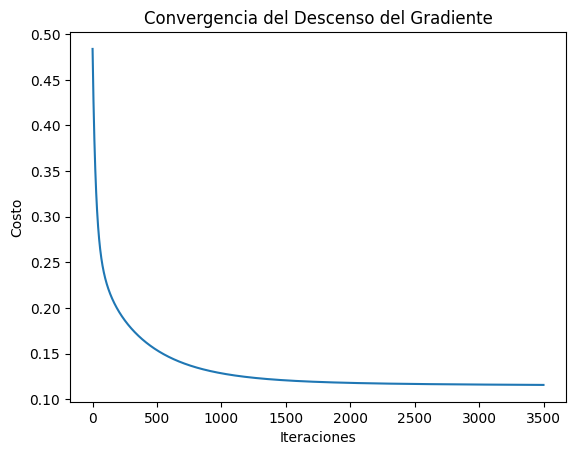

In [13]:
print("Costo final:", funcion_costo(X_train, y_train, theta))
#grafica de convergencia
plt.plot(J_historico)
plt.xlabel('Iteraciones')
plt.ylabel('Costo')
plt.title('Convergencia del Descenso del Gradiente')
plt.show()

Predicciones

In [14]:
y_test_desnorm = y_test * sigma_y + mu_y  # Desnormalizar Y de test
y_pred = X_test.dot(theta) * sigma_y + mu_y  # Predecir y desnormalizar predicciones    

print("\nPrimeras 10 predicciones vs reales:")
for real, pred in zip(y_test_desnorm[:10], y_pred[:10]):
    print(f"Real: {real:.0f}, Predicción: {pred:.2f}")



Primeras 10 predicciones vs reales:
Real: 6606, Predicción: 5424.47
Real: 1550, Predicción: 855.00
Real: 3747, Predicción: 3251.99
Real: 6041, Predicción: 5139.65
Real: 7538, Predicción: 7242.98
Real: 7264, Predicción: 5800.94
Real: 1605, Predicción: 559.04
Real: 2209, Predicción: 2437.71
Real: 7499, Predicción: 6813.32
Real: 5743, Predicción: 6805.27


In [15]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)
print("Error cuadrático medio (MSE):", np.mean((y_test_desnorm - y_pred) ** 2))
print("R² Score:", r2_score(y_test_desnorm, y_pred))

Error cuadrático medio (MSE): 910519.2887662906
R² Score: 0.7637428974831288


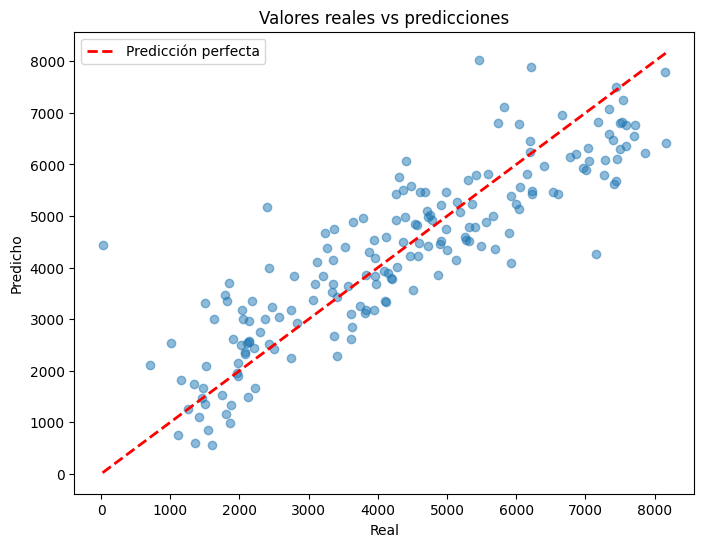

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_desnorm, y_pred, alpha=0.5)
plt.plot([y_test_desnorm.min(), y_test_desnorm.max()], 
        [y_test_desnorm.min(), y_test_desnorm.max()], 
        'r--', lw=2, label='Predicción perfecta')
plt.title("Valores reales vs predicciones")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.legend()
plt.show()